# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
405,0.048974,0.050680,0.123131,0.083844,-0.104765,-0.100895,-0.069172,-0.002592,0.036644,-0.030072,281.0
106,-0.096328,-0.044642,-0.076264,-0.043542,-0.045599,-0.034821,0.008142,-0.039493,-0.059471,-0.083920,134.0
303,0.074401,-0.044642,0.034751,0.094172,0.057597,0.020293,0.022869,-0.002592,0.073799,-0.021788,236.0
410,-0.009147,0.050680,-0.027762,0.008101,0.047965,0.037203,-0.028674,0.034309,0.066051,-0.042499,209.0
295,-0.052738,0.050680,0.039062,-0.040099,-0.005697,-0.012900,0.011824,-0.039493,0.016307,0.003064,85.0
348,0.030811,-0.044642,-0.020218,-0.005670,-0.004321,-0.029497,0.078093,-0.039493,-0.010903,-0.001078,148.0
367,-0.009147,0.050680,0.170555,0.014987,0.030078,0.033759,-0.021311,0.034309,0.033654,0.032059,242.0
132,0.016281,0.050680,-0.021295,-0.009113,0.034206,0.047850,0.000779,-0.002592,-0.012909,0.023775,107.0
223,-0.099961,-0.044642,-0.023451,-0.064199,-0.057983,-0.060186,0.011824,-0.039493,-0.018114,-0.050783,150.0
92,-0.020045,-0.044642,0.004572,0.097615,0.005311,-0.020729,0.063367,-0.039493,0.012551,0.011349,48.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
# Ver cuántos valores faltantes hay en cada columna
valores_faltantes = data.isnull().sum()
print(valores_faltantes)

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64


### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [6]:
# Imputación simple usando la media de 'bmi'
from sklearn.impute import SimpleImputer

# Guardar una copia con los datos faltantes para comparar después
data_con_faltantes = data.copy()

# Crear el imputador con estrategia de media
imputer_media = SimpleImputer(strategy='mean')

# Aplicar la imputación solo a la columna 'bmi'
data['bmi'] = imputer_media.fit_transform(data[['bmi']])

# Verificar que ya no hay valores faltantes en 'bmi'
print('Valores faltantes en bmi después de imputar:', data['bmi'].isnull().sum())

Valores faltantes en bmi después de imputar: 0


### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [7]:
# Imputación avanzada con KNNImputer
from sklearn.impute import KNNImputer

# Crear el imputador KNN (usa los 5 vecinos más cercanos)
imputer_knn = KNNImputer(n_neighbors=5)

# Copiar los datos originales con faltantes
data_knn = data_con_faltantes.copy()

# Aplicar KNN a todas las columnas
data_knn = pd.DataFrame(
    imputer_knn.fit_transform(data_knn),
    columns=data_knn.columns
)

# Comparar los resultados de ambas imputaciones
print('--- Media de bmi ---')
print('Simple (media):', round(data['bmi'].mean(), 4))
print('KNN:', round(data_knn['bmi'].mean(), 4))
print()
print('--- Media de bp ---')
print('KNN:', round(data_knn['bp'].mean(), 4))

--- Media de bmi ---
Simple (media): -0.0002
KNN: 0.0001

--- Media de bp ---
KNN: 0.0003


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

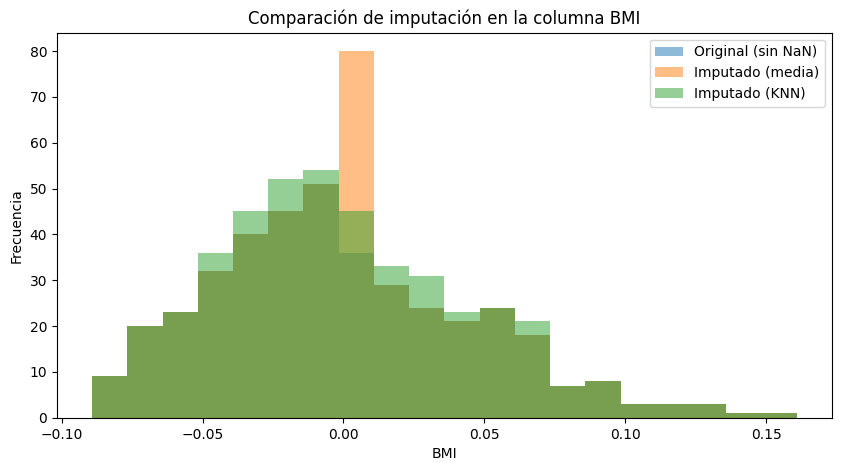

In [8]:
# Histograma: bmi antes y después de la imputación
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Histograma de los datos originales (con faltantes)
plt.hist(data_con_faltantes['bmi'].dropna(), bins=20, alpha=0.5, label='Original (sin NaN)')

# Histograma después de imputar con media
plt.hist(data['bmi'], bins=20, alpha=0.5, label='Imputado (media)')

# Histograma después de imputar con KNN
plt.hist(data_knn['bmi'], bins=20, alpha=0.5, label='Imputado (KNN)')

plt.xlabel('BMI')
plt.ylabel('Frecuencia')
plt.title('Comparación de imputación en la columna BMI')
plt.legend()
plt.show()